# ACT  10, YAHEL CARDENAS CELIS

## Generacion de la data.

primero debemos generar la data sintetica haciendo uso del codigo que el profesor nos dio en el .html

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

categories = ['Gaming', 'Tech', 'Vlog', 'Education', 'Entertainment']
channels   = ['NovaByte', 'PixelPulse', 'MindSpark', 'DailyDrift', 'CodeWave']

# Base multipliers — make aggregation results interesting
category_multiplier = {
    'Gaming': 2.5, 'Entertainment': 2.0, 'Tech': 1.5,
    'Vlog': 1.0,   'Education': 0.8
}
channel_multiplier = {
    'NovaByte': 1.8, 'PixelPulse': 1.4, 'MindSpark': 1.2,
    'DailyDrift': 0.9, 'CodeWave': 1.6
}

assigned_categories = np.random.choice(categories, n)
assigned_channels   = np.random.choice(channels, n)

cat_mult = np.array([category_multiplier[c] for c in assigned_categories])
ch_mult  = np.array([channel_multiplier[c]  for c in assigned_channels])

views    = (np.random.exponential(scale=50000, size=n) * cat_mult * ch_mult).astype(int)
views    = np.clip(views, 500, 2_000_000)

likes    = (views * np.random.uniform(0.03, 0.12, n)).astype(int)
comments = (views * np.random.uniform(0.005, 0.03, n)).astype(int)
shares   = (views * np.random.uniform(0.001, 0.015, n)).astype(int)
subs     = (views * np.random.uniform(0.002, 0.02, n)).astype(int)

duration   = np.round(np.random.uniform(5, 45, n), 1)
watch_time = np.round(duration * np.random.uniform(0.3, 0.9, n), 1)

dates = pd.date_range(start='2023-01-01', end='2024-12-31', periods=n)
dates = pd.to_datetime(np.random.choice(dates, n, replace=False))

df = pd.DataFrame({
    'video_id':               [f'VID{str(i).zfill(4)}' for i in range(1, n+1)],
    'category':               assigned_categories,
    'channel':                assigned_channels,
    'publish_date':           dates,
    'duration_minutes':       duration,
    'views':                  views,
    'likes':                  likes,
    'comments':               comments,
    'shares':                 shares,
    'subscribers_gained':     subs,
    'avg_watch_time_minutes': watch_time
})

df = df.sort_values('publish_date').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (500, 11)
  video_id       category     channel               publish_date  \
0  VID0342      Education    CodeWave 2023-01-01 00:00:00.000000   
1  VID0124           Vlog  DailyDrift 2023-01-02 11:06:36.793587   
2  VID0184           Tech  PixelPulse 2023-01-03 22:13:13.587174   
3  VID0138           Tech    CodeWave 2023-01-05 09:19:50.380761   
4  VID0129  Entertainment  DailyDrift 2023-01-06 20:26:27.174348   

   duration_minutes  views  likes  comments  shares  subscribers_gained  \
0               6.6  43743   1912      1018     509                 668   
1               5.6   6792    774       104      43                  50   
2              21.1  95385   6600      2484    1155                1856   
3              22.7  89507   8057      1797     450                1056   
4              38.5  49838   5920      1238     251                 432   

   avg_watch_time_minutes  
0                     3.3  
1                     4.4  
2                    11.7  
3  

podemos notar que el data set tiene un tamaño de 500 elementos y 11 columnas.

## Explorar el dataset.

antes de transformar la información debemos investigar que tipo de informacion tenemos.

In [2]:
# Basic structure
print(df.info())
print(df.describe())

# Check unique values in categorical columns
print(df['category'].value_counts())
print(df['channel'].value_counts())

# Check date range
print(f"Date range: {df['publish_date'].min()} → {df['publish_date'].max()}")

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   video_id                500 non-null    str           
 1   category                500 non-null    str           
 2   channel                 500 non-null    str           
 3   publish_date            500 non-null    datetime64[us]
 4   duration_minutes        500 non-null    float64       
 5   views                   500 non-null    int64         
 6   likes                   500 non-null    int64         
 7   comments                500 non-null    int64         
 8   shares                  500 non-null    int64         
 9   subscribers_gained      500 non-null    int64         
 10  avg_watch_time_minutes  500 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(5), str(3)
memory usage: 43.1 KB
None
                     publish_date  duration

Podemos apreciar que tenemos 500 elementos, 11 columnas y que no existen valores de tipo NaN.

Podemos notar 4 tipos de datos:

1. Fechas formato  (US).
2. Enteros.
3. Flotantes.
4. Strings.

la variedad de datos nos permitira clasificar por categorias que nosotros definamos, solo si asi lo queremos.

## Manejo de columnas.

In [3]:
df['year']        = df['publish_date'].dt.year
df['month']       = df['publish_date'].dt.month
df['month_name']  = df['publish_date'].dt.strftime('%B')
df['quarter']     = df['publish_date'].dt.quarter
df['day_of_week'] = df['publish_date'].dt.day_name()

In [4]:
# How many videos were published per quarter?
print(df.groupby(['year', 'quarter'])['video_id'].count())

# Which day of the week has the most uploads?
print(df['day_of_week'].value_counts())

year  quarter
2023  1          62
      2          62
      3          63
      4          63
2024  1          62
      2          62
      3          63
      4          63
Name: video_id, dtype: int64
day_of_week
Sunday       73
Monday       72
Friday       72
Wednesday    72
Tuesday      71
Thursday     70
Saturday     70
Name: count, dtype: int64


Se nos pide contestar las siguientes 2 preguntas.
1. ¿Cuantos videos fueron publicados por cuatrimestre?
2. ¿Qué dia de la semana tiene la mayor cantidad de uploads?

Respondiendo estas preguntas sin utilizar medidas de tendencia central podemos notar que la tendencia es que por cuatrimestre se publiquen entre 62 o 63 videos por cuatrimestre.

Aparte de esto podemos notar que el día con mayo numero de uploads es domingo con una cantidad 73 videos cargados.

In [6]:
# calculando el promedio de videos subidos por cuatrimestre
videos_per_quarter = df.groupby(['year', 'quarter'])['video_id'].count()
average_videos_per_quarter = videos_per_quarter.mean()
print(f"Promedio de videos subidos por cuatrimestre: {average_videos_per_quarter}")

Promedio de videos subidos por cuatrimestre: 62.5


Ahora podemos decir con claridad que por cuatrimestre se suben 62.5 videos.

### Visualizacion de uploads de la semana.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

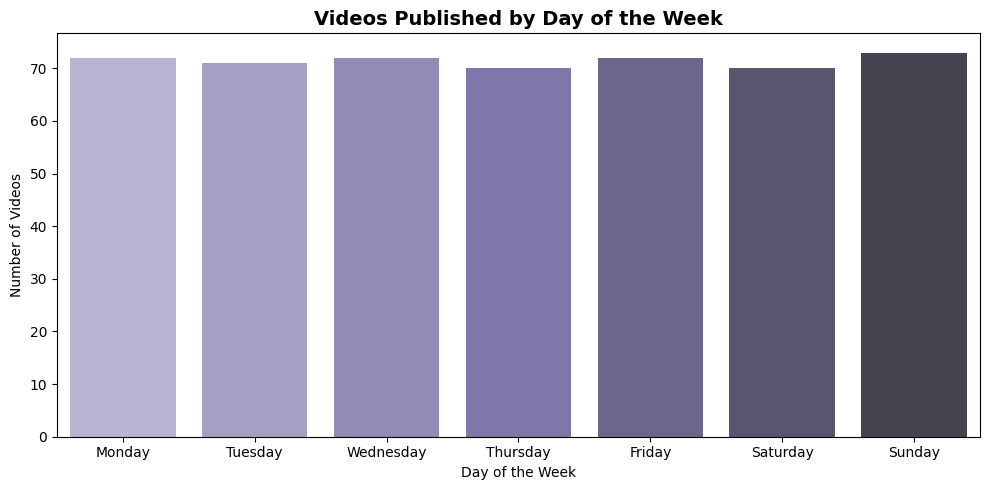

In [ ]:
day_order  = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=day_counts.index, y=day_counts.values,
            hue=day_counts.index, palette='Purples_d', legend=False)
plt.title('Videos Published by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Videos')
plt.tight_layout()
plt.savefig('uploads_by_day.png', dpi=150)
plt.show()

## Columnas calculadas.

In [9]:
# Engagement Rate: how much the audience interacts relative to views
df['engagement_rate'] = ((df['likes'] + df['comments'] + df['shares']) / df['views'] * 100).round(2)

# Like Ratio: what percentage of viewers liked the video
df['like_ratio'] = (df['likes'] / df['views'] * 100).round(2)

# Retention Rate: how much of the video viewers actually watched
df['retention_rate'] = (df['avg_watch_time_minutes'] / df['duration_minutes'] * 100).round(2)

# Virality Score: shares per 1000 views
df['virality_score'] = (df['shares'] / df['views'] * 1000).round(2)

In [10]:
df['performance_tier'] = pd.cut(
    df['engagement_rate'],
    bins=[0, 5, 10, 20, 100],
    labels=['Low', 'Medium', 'High', 'Viral']
)

print(df['performance_tier'].value_counts())

performance_tier
High      257
Medium    238
Low         5
Viral       0
Name: count, dtype: int64


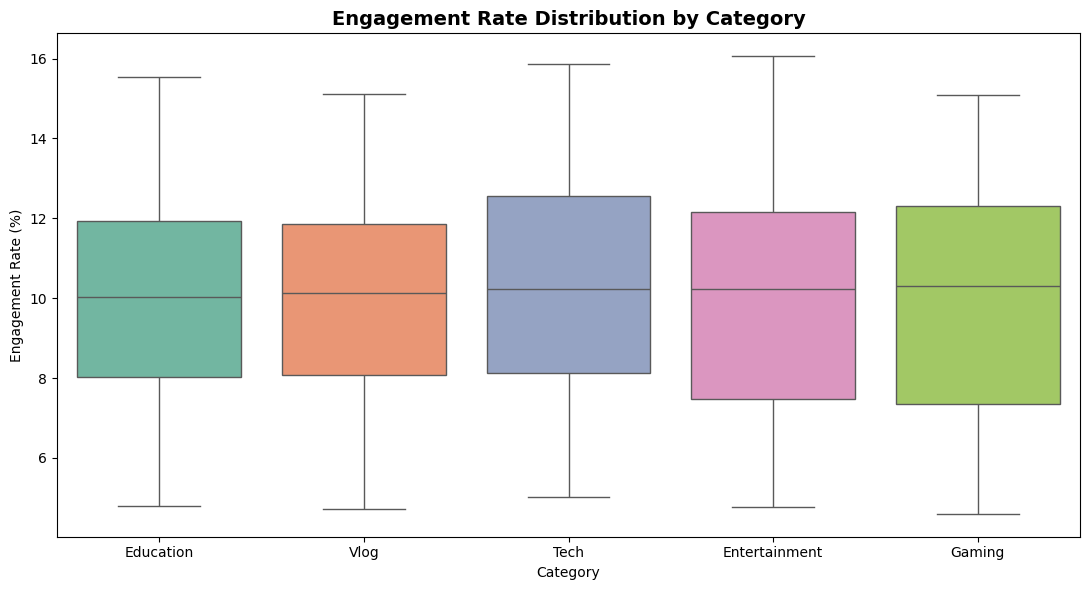

In [12]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x='category', y='engagement_rate',
            hue='category', palette='Set2', legend=False)
plt.title('Engagement Rate Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Engagement Rate (%)')
plt.tight_layout()
plt.savefig('engagement_by_category.png', dpi=150)
plt.show()

En esta grafica podemos notar que el area con mas engagement es "tech cathegory" y la que menos tiene es "Gaming" seguido de "Entretainement".

## GroupBy & Aggregation.

### Aggregation by channel

In [13]:
category_stats = df.groupby('category').agg(
    video_count    = ('video_id',            'count'),
    total_views    = ('views',               'sum'),
    avg_views      = ('views',               'mean'),
    max_views      = ('views',               'max'),
    avg_engagement = ('engagement_rate',     'mean'),
    med_engagement = ('engagement_rate',     'median'),
    total_subs     = ('subscribers_gained',  'sum')
).round(2).sort_values('total_views', ascending=False)

print(category_stats)

               video_count  total_views  avg_views  max_views  avg_engagement  \
category                                                                        
Gaming                 109     17893615  164161.61     623135            9.95   
Entertainment           93     12395532  133285.29     950408           10.04   
Tech                    95      9554064  100569.09     741863           10.29   
Education              112      7349253   65618.33     421310           10.09   
Vlog                    91      5732988   62999.87     263998            9.94   

               med_engagement  total_subs  
category                                   
Gaming                  10.31      199724  
Entertainment           10.23      130043  
Tech                    10.23      109059  
Education               10.02       76409  
Vlog                    10.14       64257  


En la tarea se nos pide que respondamos cual es la categoria con mas numero de vistas totales, en este caso es "Gaming" pero no es la categoria con más engagement.

La categoria con más engagement es "Tech".

### Aggregation by chanel

In [14]:
channel_stats = df.groupby('channel').agg(
    video_count    = ('video_id',            'count'),
    total_views    = ('views',               'sum'),
    avg_engagement = ('engagement_rate',     'mean'),
    avg_retention  = ('retention_rate',      'mean'),
    total_subs     = ('subscribers_gained',  'sum')
).round(2).sort_values('total_views', ascending=False)

print(channel_stats)

            video_count  total_views  avg_engagement  avg_retention  \
channel                                                               
CodeWave            111     15087999           10.17          59.05   
NovaByte            101     11982437            9.83          58.93   
PixelPulse           95      9594392           10.28          59.39   
MindSpark            99      8784560            9.97          56.55   
DailyDrift           94      7476064           10.06          62.31   

            total_subs  
channel                 
CodeWave        176084  
NovaByte        128481  
PixelPulse       98971  
MindSpark        99166  
DailyDrift       76790  


Se nos pide contestar a la pregunta ¿Qué canal tiene el mejor promedio de retencion? ¿Es el mismo con el mayor numero de vistas total?

La respuesta es que el canal con mejor retencion es "DailyDrift" y el canal con mayor numero de vistas totales es "CodeWave".

## Monthly aggregation with resample

In [15]:
# Set publish_date as index for time-based resampling
df_time = df.set_index('publish_date')

monthly = df_time.resample('ME').agg(
    video_count    = ('video_id',        'count'),
    total_views    = ('views',           'sum'),
    avg_engagement = ('engagement_rate', 'mean')
).round(2)

print(monthly)
print(f"\nTop 3 months by views:\n{monthly['total_views'].nlargest(3)}")

              video_count  total_views  avg_engagement
publish_date                                          
2023-01-31             22      2083776           10.36
2023-02-28             19      2521353            9.94
2023-03-31             21      3024095            9.56
2023-04-30             21      1966295            9.91
2023-05-31             21      2034089            9.64
2023-06-30             20      1344838           11.48
2023-07-31             21      2048929            9.98
2023-08-31             22      1185942           10.32
2023-09-30             20      1799567            9.36
2023-10-31             21      1432262           11.28
2023-11-30             21      2312116           10.90
2023-12-31             21      1773534           10.48
2024-01-31             21      1768957            9.91
2024-02-29             20      2534009           10.05
2024-03-31             21      1915482            9.90
2024-04-30             21      1985463            9.59
2024-05-31

### Visualization - montly views and engagement rate

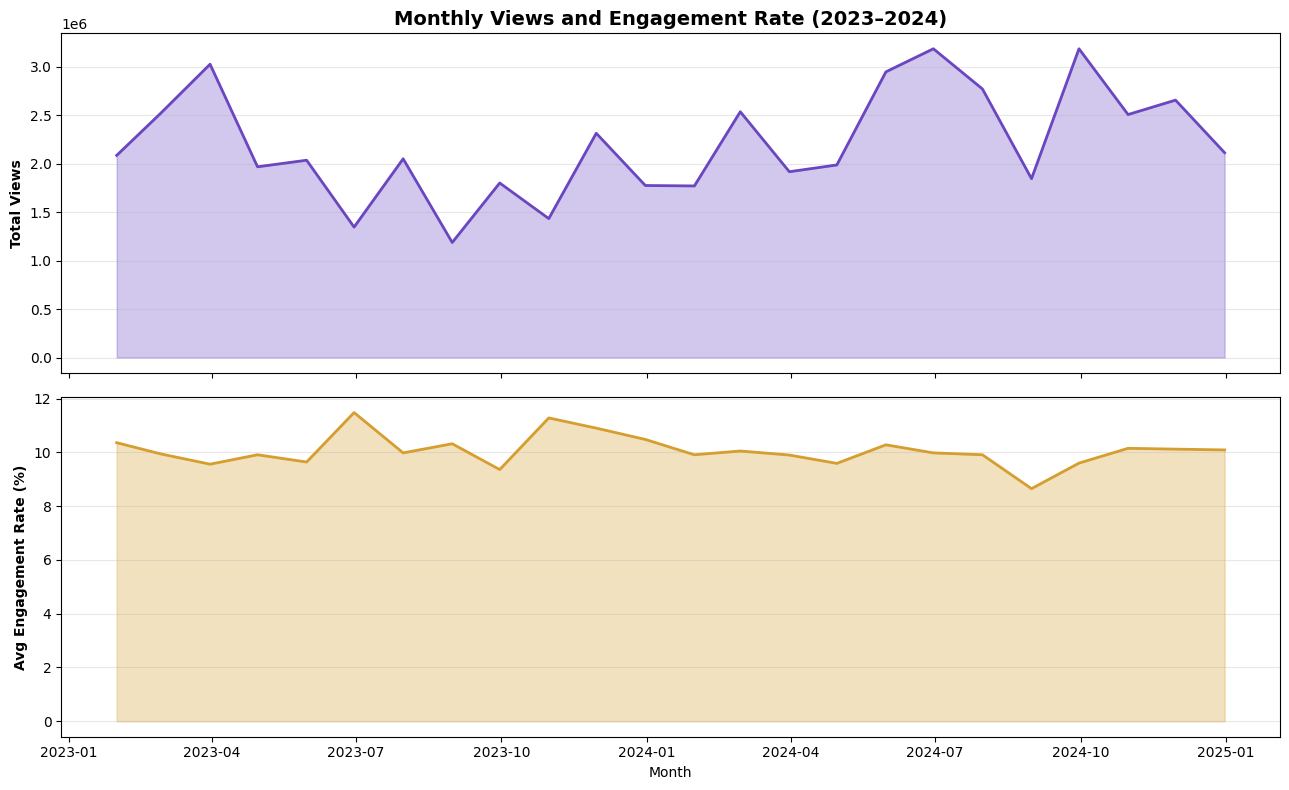

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# --- Top subplot: Total Views ---
ax1.fill_between(monthly.index, monthly['total_views'], alpha=0.3, color='#6B46C1')
ax1.plot(monthly.index, monthly['total_views'], color='#6B46C1', linewidth=2)
ax1.set_ylabel('Total Views', fontweight='bold')
ax1.set_title('Monthly Views and Engagement Rate (2023–2024)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# --- Bottom subplot: Avg Engagement Rate ---
ax2.plot(monthly.index, monthly['avg_engagement'], color='#D69E2E', linewidth=2)
ax2.fill_between(monthly.index, monthly['avg_engagement'], alpha=0.3, color='#D69E2E')
ax2.set_ylabel('Avg Engagement Rate (%)', fontweight='bold')
ax2.set_xlabel('Month')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('monthly_trends.png', dpi=150)
plt.show()

### Visualization — Engagement Heatmap by Channel & Category

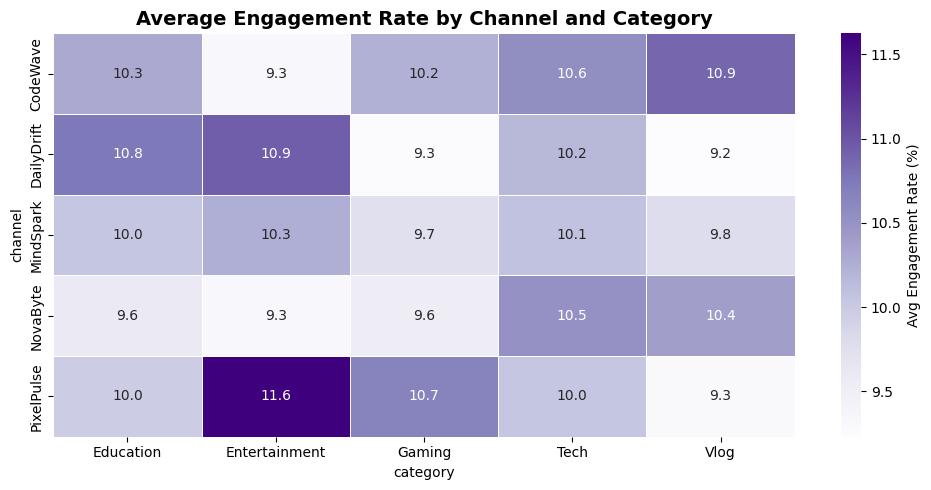

In [17]:
heatmap_data = df.groupby(['channel', 'category'])['engagement_rate'].mean().unstack()

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Purples',
            linewidths=0.5, cbar_kws={'label': 'Avg Engagement Rate (%)'})
plt.title('Average Engagement Rate by Channel and Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('engagement_heatmap.png', dpi=150)
plt.show()

## Pivot Tables

### Part 1 — Average Views by Category and Channel

In [18]:
pivot_views = pd.pivot_table(
    df,
    values='views',
    index='category',
    columns='channel',
    aggfunc='mean'
).round(0)

print(pivot_views)

channel        CodeWave  DailyDrift  MindSpark  NovaByte  PixelPulse
category                                                            
Education       63487.0     37403.0    48692.0   93574.0     75245.0
Entertainment  119359.0    126899.0   106871.0  198035.0    119209.0
Gaming         243015.0    141918.0   132826.0  151277.0    140225.0
Tech           156587.0     61384.0    95828.0   76453.0    106142.0
Vlog            56062.0     49506.0    71774.0   75262.0     60711.0


se nos pide contestar ¿Qué combinacion entre categoria y canal logra obtener el promedio más alto de vistas? ¿Hay canales especificos en algunas categorias?

para responder a esta pregunta tenemos que identificar cuales fueron los canales con el promedio más alto en cada categoria, nos quedaria una lista como la siguiente:

1. NovaByte / Education: 93574.0
2. NovaByte / Entertainement: 198035.0
3. CodeWave / Gaming: 243015.0
4. CodeWave / Tech: 156587.0
5. NovaByte / Vlog: 75262.0

Podemos notar que NovaByte tiene dominancia en casi todas las categorias, solo siendo destronada en gaming y tech por CodeWave.



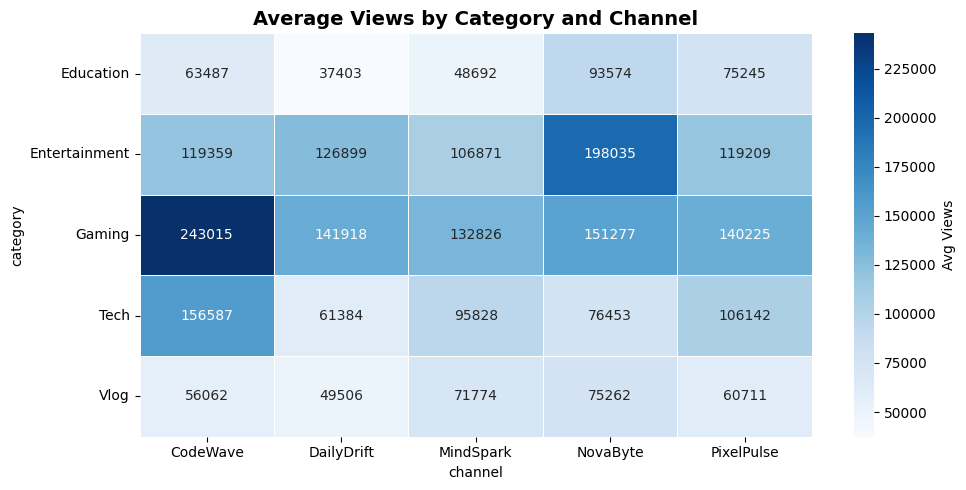

In [19]:
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_views, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Avg Views'})
plt.title('Average Views by Category and Channel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pivot_views.png', dpi=150)
plt.show()

## Part 2 — Engagement Rate by Month and Category

In [20]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

pivot_engagement = pd.pivot_table(
    df,
    values='engagement_rate',
    index='month_name',
    columns='category',
    aggfunc='mean'
).round(2).reindex(month_order)

print(pivot_engagement)

category    Education  Entertainment  Gaming   Tech   Vlog
month_name                                                
January          9.33          11.40    9.43  11.30  10.09
February         9.17          10.07    9.94   9.69  11.26
March            8.31          10.42    9.36  10.88   9.13
April            9.52          10.96    9.83   9.04   9.48
May             10.11           8.58    9.91  10.28  10.69
June            10.59          11.63   10.52  10.87  10.26
July            10.10           9.13   10.29  10.27   9.99
August           8.71           9.53    9.12  10.58   9.63
September       10.51           8.86    9.33   9.33   9.54
October         11.51           9.64   11.48  10.59   7.52
November        10.75          10.28   10.48  10.05  10.91
December        10.86          10.34   10.68   9.94   9.47


¿Qué mes muestra la mayor cantidad de engagement para cada categoria? ¿Notaste algun patron de temporada a lo largo de los dos años?

1. Enero / Entertainment: 11.40
2. Febrero / Vlog: 11.26
3. Marzo / Tech: 10.88
4. Abril / Entertainment: 10.96
5. Mayo / Vlog: 10.69
6. Junio / Entertainement: 11.63
7. Julio / Gaming: 10.29
8. Agosto / Tech: 10.58
9. Septiembre / Education: 10.51
10. Octubre / Education: 11.51
11. Noviembre / Vlog: 10.91
12. Diciembre / Education: 10.86

suponiendo que la poblacion tiene una edad de entre 12 a 23 años aproximadamente, podemos notar que hay un patron con la educacion. Los alumnos se preparan para el inicio de semestre en septiembre y en diciembre, despues de prepararse lo suficiente para el resto del año pueden permitirse cambiar de contenido.

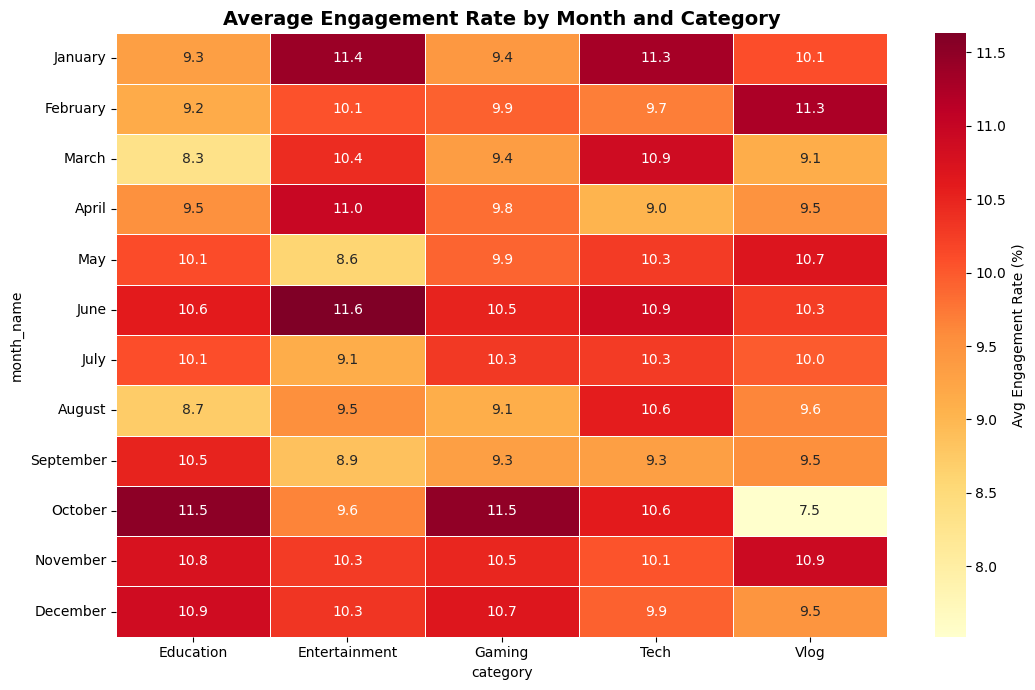

In [21]:
plt.figure(figsize=(11, 7))
sns.heatmap(pivot_engagement, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Avg Engagement Rate (%)'})
plt.title('Average Engagement Rate by Month and Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pivot_engagement.png', dpi=150)
plt.show()

## Part 3 — Retention Rate by Channel and Quarter

In [22]:
pivot_retention = pd.pivot_table(
    df,
    values='retention_rate',
    index='channel',
    columns='quarter',
    aggfunc='median'
).round(2)

pivot_retention.columns = [f'Q{q}' for q in pivot_retention.columns]
print(pivot_retention)

               Q1     Q2     Q3     Q4
channel                               
CodeWave    62.50  53.58  62.24  54.01
DailyDrift  69.20  59.81  55.12  71.24
MindSpark   53.02  62.65  54.78  43.72
NovaByte    48.33  58.78  59.49  64.72
PixelPulse  55.47  57.80  57.22  67.89


se nos pide contestar a lo siguiente ¿Hay algún canal que muestre una mejora constante en la tasa de retención a lo largo de los trimestres? ¿Cómo se podría explicar esa tendencia?

El canal que tiene una taza de retencion que mejora conforme el tiempo es NovaByte, muy probablemente se a un canal más de nicho haciendole más dificil crecer en numeros pero facilitandole la obtension de una fanbase muy leal.

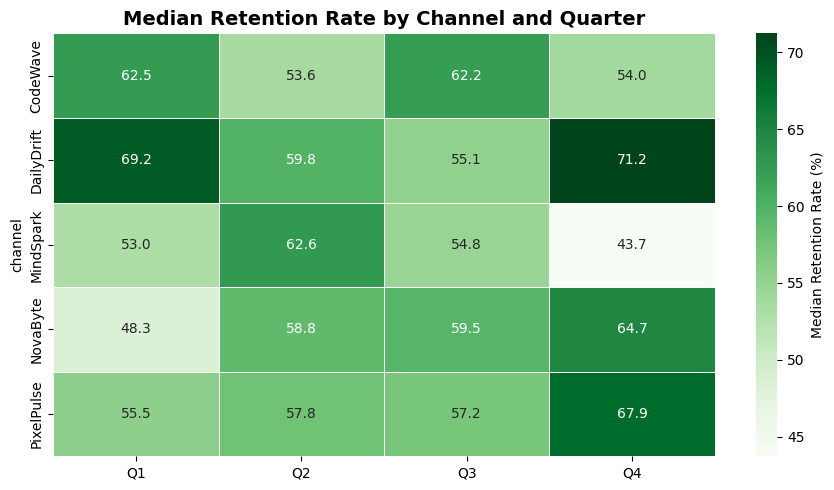

In [23]:
plt.figure(figsize=(9, 5))
sns.heatmap(pivot_retention, annot=True, fmt='.1f', cmap='Greens',
            linewidths=0.5, cbar_kws={'label': 'Median Retention Rate (%)'})
plt.title('Median Retention Rate by Channel and Quarter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pivot_retention.png', dpi=150)
plt.show()

## Esport transformed dataset.

In [24]:
df.to_csv('youtube_transformed.csv', index=False)
print(f"Exported dataset with {len(df.columns)} columns and {len(df)} rows.")

Exported dataset with 21 columns and 500 rows.


In [25]:
pivot_views.to_csv('pivot_views.csv')
pivot_engagement.to_csv('pivot_engagement.csv')
pivot_retention.to_csv('pivot_retention.csv')
print("All pivot tables exported successfully.")

All pivot tables exported successfully.
